<a href="https://colab.research.google.com/github/va23727/CI345_ML/blob/main/lab10_lab11_disicion_tree_and_svm_for_weather.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Lab10 Decision Tree for Weather

##Step 1 : Loading* Data

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive

#Mount Google Drive
drive.mount('/content/drive')

# Path to your CSV in Drive
Weather_file = '/content/drive/MyDrive/CI345_ML/data/Weather.csv'

Weather_table = pd.read_csv(Weather_file)
Weather_table.head(2)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Day,Outlook,Temp,Humidity,Wind,PlayTennis
0,D1,Sunny,Hot,High,Weak,No
1,D2,Sunny,Hot,High,Strong,No


##Step 2 : Basic Data Analysis

In [ ]:
df = Weather_table.copy()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Day         14 non-null     object
 1   Outlook     14 non-null     object
 2   Temp        14 non-null     object
 3   Humidity    14 non-null     object
 4   Wind        14 non-null     object
 5   PlayTennis  14 non-null     object
dtypes: object(6)
memory usage: 804.0+ bytes


In [ ]:
df.columns

Index(['Day', 'Outlook', 'Temp', 'Humidity', 'Wind', 'PlayTennis'], dtype='object')

In [ ]:
df.shape

(14, 6)

In [ ]:
df.isnull().sum()

,0
Day,0
Outlook,0
Temp,0
Humidity,0
Wind,0
PlayTennis,0


##Step 3 : Data Visualization

<Axes: xlabel='PlayTennis'>

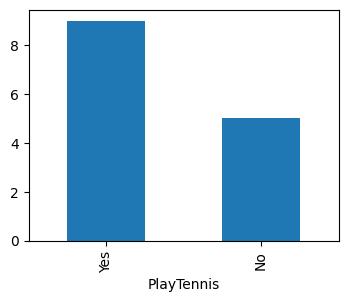

In [ ]:

df = Weather_table.copy()
res = df.PlayTennis.value_counts()
res.plot(kind = 'bar', figsize=(4,3))

##Step 4 : Processing data

### Method 1 : Use LabelEncoder

In [ ]:
df = Weather_table.copy()

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

df['Humidity']= le.fit_transform(df['Humidity'])
df['Wind']= le.fit_transform(df['Wind'])

df.head(1)

,Day,Outlook,Temp,Humidity,Wind,PlayTennis
0,D1,Sunny,Hot,0,1,No


In [ ]:
print(df.Outlook.unique())
print(df.Temp.unique())


['Sunny' 'Overcast' 'Rain']
['Hot' 'Mild' 'Cool' 'Cold']


###Method 2 : Use Mapping

In [ ]:
df = Weather_table.copy()

df['Outlook'] = df['Outlook'].map({'Sunny':0,'Overcast':1,'Rain':2})
df['PlayTennis'] = df['PlayTennis'].map({'No':0,'Yes':1})
df['Temp'] = df['Temp'].map({'Hot':0,'Mild':1,'Cool':2, 'Cold': 3})
df['Humidity'] = df['Humidity'].map({'High':0,'Normal':1})
df['Wind'] = df['Wind'].map({'Weak':0,'Strong':1})
df.head(14)

,Day,Outlook,Temp,Humidity,Wind,PlayTennis
0,D1,0,0,0,0,0
1,D2,0,0,0,1,0
2,D3,1,0,0,0,1
3,D4,2,1,0,0,1
4,D5,2,2,1,0,1
5,D6,2,2,1,1,0
6,D7,1,2,1,0,1
7,D8,0,1,0,0,0
8,D9,0,3,1,0,1
9,D10,2,1,1,1,1


##Step 5 : Get Data and Target

In [ ]:
data = df[['Outlook','Temp','Humidity','Wind']]
target = df['PlayTennis']
data.head(2)
target.head(2)

,PlayTennis
0,0
1,0


##Step 6 : Claaification by Decision Tree

In [ ]:
# Step : Split Dataset
from sklearn.model_selection import train_test_split

data_train, data_test, target_train, target_test  = train_test_split (data, target, random_state = 13, test_size = 0.4)

# What is the output
print(data_train.shape)
print(data_test.shape)

print(target_train.shape)
print(target_test.shape)

(8, 4)
(6, 4)
(8,)
(6,)


In [ ]:
from sklearn import tree
df__classifier = tree.DecisionTreeClassifier(max_depth=5)

df__classifier.fit(X = data_train, y = target_train)

print(df__classifier)

predicted = df__classifier.predict(X = data_test)
print(predicted)

#Classification report
from sklearn.metrics import classification_report
report = classification_report(target_test, predicted)
print(report)

#Use Confusion_matrix
from sklearn.metrics import confusion_matrix
matrix = confusion_matrix(y_true = target_test, y_pred = predicted)
print(matrix)

DecisionTreeClassifier(max_depth=5)
[1 0 1 1 1 0]
              precision    recall  f1-score   support

           0       0.50      0.50      0.50         2
           1       0.75      0.75      0.75         4

    accuracy                           0.67         6
   macro avg       0.62      0.62      0.62         6
weighted avg       0.67      0.67      0.67         6

[[1 1]
 [1 3]]


#LAb 11 : Use SVM

In [ ]:
#Show training and testing data
#what is the look like

print(data_train[:3])
print(data_test[:3])

print(target_train[:3])
print(target_test[:3])


    Outlook  Temp  Humidity  Wind
1         0     0         0     1
4         2     2         1     0
13        2     1         0     1
    Outlook  Temp  Humidity  Wind
9         2     1         1     1
11        1     1         0     1
5         2     2         1     1
1     0
4     1
13    0
Name: PlayTennis, dtype: int64
9     1
11    1
5     0
Name: PlayTennis, dtype: int64


In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report

# Create SVM classifier

svm_classifier = SVC(kernel='sigmoid')
# Use traning dataset to train classifier

svm_classifier.fit(X = data_train, y = target_train)

# Use testing dataset to test classifier

predicted = svm_classifier.predict(X = data_test)

# print the confusion matrix and score report
report = classification_report(target_test, predicted)
print(report)

#Use Confusion_matrix
from sklearn.metrics import confusion_matrix
matrix = confusion_matrix(y_true = target_test, y_pred = predicted)
print(matrix)
print('------')
print(predicted)
actual = target_test
print(actual)

              precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       0.80      1.00      0.89         4

    accuracy                           0.83         6
   macro avg       0.90      0.75      0.78         6
weighted avg       0.87      0.83      0.81         6

[[1 1]
 [0 4]]
------
[1 1 1 1 1 0]
9     1
11    1
5     0
3     1
8     1
7     0
Name: PlayTennis, dtype: int64


#USE KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

for k in range(1, 9, 2):
  print(F"\n--- Applying NN with k = {k} ---")
  knn_classifier = KNeighborsClassifier(n_neighbors=k)
  knn_classifier.fit(X = data_train, y = target_train)

  predicted = knn_classifier.predict(X = data_test)
  report = classification_report(target_test, predicted)
  print(report)


--- Applying NN with k = 1 ---
              precision    recall  f1-score   support

           0       0.25      0.50      0.33         2
           1       0.50      0.25      0.33         4

    accuracy                           0.33         6
   macro avg       0.38      0.38      0.33         6
weighted avg       0.42      0.33      0.33         6


--- Applying NN with k = 3 ---
              precision    recall  f1-score   support

           0       0.50      0.50      0.50         2
           1       0.75      0.75      0.75         4

    accuracy                           0.67         6
   macro avg       0.62      0.62      0.62         6
weighted avg       0.67      0.67      0.67         6


--- Applying NN with k = 5 ---
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.67      1.00      0.80         4

    accuracy                           0.67         6
   macro avg       0.33      0.5

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m